<a href="https://colab.research.google.com/github/S1h2l/color-image-processing-/blob/main/L_a_b_Conversion_Equations_question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow


In [ ]:
C1 = np.uint8([[[64, 192, 96]]])
C2 = np.uint8([[[168, 255, 128]]])
C3 = np.uint8([[[64, 66, 96]]])

In [ ]:
def rgb_to_lab(color):
    bgr = cv2.cvtColor(color, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    return lab[0][0]

In [ ]:
lab1 = rgb_to_lab(C1)
lab2 = rgb_to_lab(C2)
lab3 = rgb_to_lab(C3)
print("C1 LAB:", lab1)
print("C2 LAB:", lab2)
print("C3 LAB:", lab3)

C1 LAB: [177  73 166]
C2 LAB: [236  80 180]
C3 LAB: [ 74 135 110]


In [ ]:
def distance(cA, cB):
    return np.linalg.norm(cA[0][0] - cB[0][0])
print("RGB Distance C1-C2:", distance(C1, C2))
print("RGB Distance C1-C3:", distance(C1, C3))
print("RGB Distance C2-C3:", distance(C2, C3))

RGB Distance C1-C2: 332.45902003104084
RGB Distance C1-C3: 126.0
RGB Distance C2-C3: 218.0848458742606


In [ ]:
def lab_distance(lA, lB):
    return np.linalg.norm(lA - lB)
print("LAB Distance C1-C2:", lab_distance(lab1, lab2))
print("LAB Distance C1-C3:", lab_distance(lab1, lab3))
print("LAB Distance C2-C3:", lab_distance(lab2, lab3))

LAB Distance C1-C2: 399.216733116236
LAB Distance C1-C3: 226.67377439836307
LAB Distance C2-C3: 267.47897113605023


In [ ]:
def imshow(img):
  cv.imshow("..",img)
  cv.waitkey(0)
  cv.destroyAllWindows()

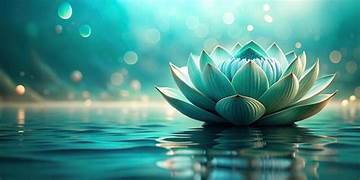

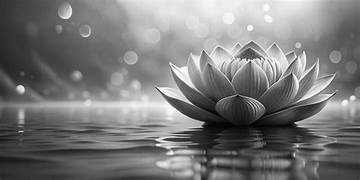

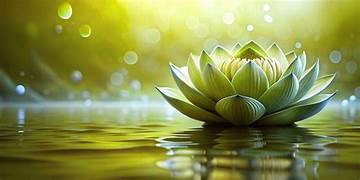

In [ ]:
v2 = cv.imread("/content/OIP (1).jpg")

cv2_imshow(v2)

v2Gray = cv.cvtColor(v2, cv.COLOR_BGR2GRAY)
cv2_imshow(v2Gray)

v2RGB = cv.cvtColor(v2, cv.COLOR_BGR2RGB)
cv2_imshow(v2RGB)



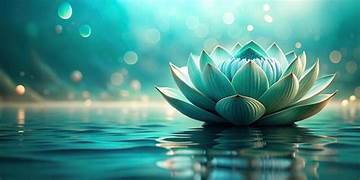

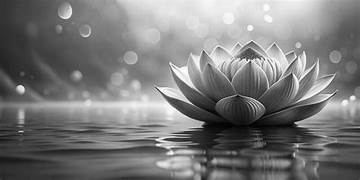

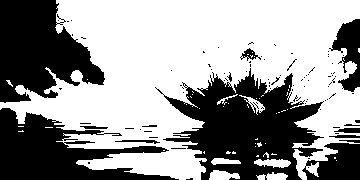

In [ ]:
v2 = cv.imread("/content/OIP (1).jpg")
cv2_imshow(v2)

v2Gray = cv.cvtColor(v2, cv.COLOR_BGR2GRAY)
v2Gray = np.expand_dims(v2Gray, axis=2)
cv2_imshow(v2Gray)

v2k = v2Gray.reshape((-1,1))
v2k = np.float32(v2k)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3
_, labels, centres = cv.kmeans(v2k, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

centres = np.uint8(centres)
labels = labels.flatten()

segmented_image = centres[labels]
segmented_image = segmented_image.reshape(v2Gray.shape)

bgnd_label = labels[0]
labels_2D = labels.reshape(v2Gray.shape)
segmented_image[labels_2D == bgnd_label] = 0
segmented_image[labels_2D != bgnd_label] = 255
cv2_imshow(segmented_image)

